In [43]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
import requests

In [44]:
from dotenv import load_dotenv
load_dotenv()

True

In [45]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()
results = search_tool.invoke('top news in india today')
results

"5 hours ago - In open letter, over 2,000 citizens urge CJI to halt SIR, seek probe into ECI · Pincky Balhara becomes India's Kurash legend with bronze medal in Nagoya India at Asian Games 2026 Day 10: Today's medal tally, results and Live Updates: Real-time news about India's Day 10 campaign at the 2026 Asian Games across all events with a spotlight on shooting, squash and athletics ... Vvaan box office collection day 3: Sidharth Malhotra's film scored Rs 33.35 crore, his biggest opening weekend in India since Brothers (2015). 6 days ago - F-35 fighter jets, 200+ airmen arrive as US participates in India's Tarang Shakti air exercise · Tamil Nadu govt rolls back law and order department’s RTI exemption amid backlash · NEET-PG 2026 result out: 2.65 lakh candidates appeared, ... 2 hours ago - Investors Lose Rs 5 Lakh Crore In An Hour: 5 Reasons Behind Market Crash Today · 4 hours ago · By Prateek Shukla · See more headlines and perspectives · rediff.com · More · Bank Unions Postpone Nati

In [46]:
llm = ChatGoogleGenerativeAI(model='gemini-3.1-flash-lite')

In [47]:
from langchain_classic.agents import create_react_agent, AgentExecutor

In [48]:
from langsmith import Client

# Initialize the underlying client directly
client = Client()

# Pull the reAct prompt from langsmith (reAct stands for Reasoning and Action)
# Pull the public prompt safely using the proper security flag
prompt = client.pull_prompt("hwchase17/react", dangerously_pull_public_prompt=True)


In [49]:
agent = create_react_agent(
    llm=llm,
    tools=[search_tool],
    prompt=prompt
)

In [50]:
agent_executor = AgentExecutor(
    agent=agent,
    tools=[search_tool],
    verbose=True)

In [51]:
response = agent_executor.invoke({"input":"3 ways to reach Goa from Ahmedabad"})
print(response)



> Entering new AgentExecutor chain...
Thought: I need to find three different ways to travel from Ahmedabad to Goa.

Action: duckduckgo_search
Action Input: ways to reach Goa from AhmedabadTraveling from Ahmedabad to Goa covers a distance of over 800 kilometers, with multiple modes of transport available including flight, train, bus, and cab. The fastest and recommended way to get from Ahmedabad to Goa is by flight, which takes approximately 2 hours with several direct services. There are 6 ways to get from Ahmedabad to Goa by plane, train, bus, or car Select an option below to see step-by-step directions and to compare ticket prices and travel times in Rome2Rio's travel planner. Looking for a comfortable and budget-friendly train journey from Ahmedabad to Goa? With 10+ trains operating on this route, MakeMyTrip helps you explore timings, schedules, compare classes (3A,1A,2A,SL), and find the right option based on timetable, duration, pricing, or departure station. ... This guide wil

### How an Agent Works

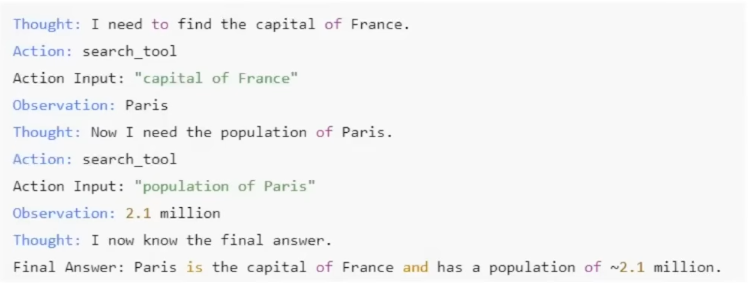